In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Version PyTorch :", torch.__version__)

Version PyTorch : 2.11.0+cpu


In [3]:


import os
import glob
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

FOLDER_PATH = "/content/drive/MyDrive/stocks"

csv_files = glob.glob(os.path.join(FOLDER_PATH, "*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"Aucun fichier CSV trouvé dans le dossier : {FOLDER_PATH}"
    )

DATA_PATH = csv_files[0]

print("Fichier trouvé :", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset chargé avec succès.")
print("Dimensions du dataset :", df.shape)

display(df.head())

print("\nInformations sur le dataset :")
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fichier trouvé : /content/drive/MyDrive/stocks/SOHOO.csv

Dataset chargé avec succès.
Dimensions du dataset : (623, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-10-10,25.049999,25.049999,25.049999,25.049999,19.498295,2000
1,2017-10-11,25.180000,25.200001,24.900000,25.180000,19.599482,33000
2,2017-10-12,25.180000,25.299999,25.160000,25.200001,19.615049,27200
3,2017-10-13,25.200001,25.400000,25.110001,25.230000,19.638401,33300
4,2017-10-16,25.250000,25.299999,25.200001,25.250000,19.653967,25200



Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       623 non-null    object 
 1   Open       623 non-null    float64
 2   High       623 non-null    float64
 3   Low        623 non-null    float64
 4   Close      623 non-null    float64
 5   Adj Close  623 non-null    float64
 6   Volume     623 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 34.2+ KB


In [4]:


print("Colonnes du dataset :")
print(df.columns.tolist())

df = df.drop_duplicates()

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.sort_values("Date")

print("\nValeurs manquantes avant traitement :")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nValeurs manquantes après traitement :")
print(df.isnull().sum())

Colonnes du dataset :
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Valeurs manquantes avant traitement :
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Valeurs manquantes après traitement :
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [5]:

if "Close" not in df.columns:
    raise ValueError("La colonne 'Close' est introuvable dans le dataset.")

df["Target"] = df["Close"].shift(-1)

df = df.dropna()

display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume,Target
0,2017-10-10,25.049999,25.049999,25.049999,25.049999,19.498295,2000,25.180000
1,2017-10-11,25.180000,25.200001,24.900000,25.180000,19.599482,33000,25.200001
2,2017-10-12,25.180000,25.299999,25.160000,25.200001,19.615049,27200,25.230000
3,2017-10-13,25.200001,25.400000,25.110001,25.230000,19.638401,33300,25.250000
4,2017-10-16,25.250000,25.299999,25.200001,25.250000,19.653967,25200,25.250000


In [6]:


features = df.select_dtypes(include=[np.number]).columns.tolist()

features.remove("Target")

print("Variables utilisées pour prédire :")
print(features)

X_data = df[features].values
y_data = df[["Target"]].values

print("Forme de X_data :", X_data.shape)
print("Forme de y_data :", y_data.shape)

Variables utilisées pour prédire :
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
Forme de X_data : (622, 6)
Forme de y_data : (622, 1)


In [7]:


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

print("Exemple X normalisé :")
print(X_scaled[:3])

print("\nExemple y normalisé :")
print(y_scaled[:3])

Exemple X normalisé :
[[0.92252756 0.91315942 0.93181812 0.92394354 0.75442459 0.00992063]
 [0.92792493 0.91961443 0.92561979 0.92938816 0.75898933 0.16369048]
 [0.92792493 0.92391766 0.9363636  0.9302258  0.75969163 0.13492063]]

Exemple y normalisé :
[[0.92938816]
 [0.9302258 ]
 [0.93148219]]


In [8]:


def create_sequences(X, y, sequence_length=30):
    """
    Cette fonction crée des séquences pour le LSTM.

    Exemple :
    Les 30 derniers jours → prédire le prix du lendemain
    """

    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length])

    return np.array(X_seq), np.array(y_seq)


SEQUENCE_LENGTH = 30

X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    sequence_length=SEQUENCE_LENGTH
)

print("Forme de X_seq :", X_seq.shape)
print("Forme de y_seq :", y_seq.shape)

Forme de X_seq : (592, 30, 6)
Forme de y_seq : (592, 1)


In [9]:


n = len(X_seq)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]

X_val = X_seq[train_size:train_size + val_size]
y_val = y_seq[train_size:train_size + val_size]

X_test = X_seq[train_size + val_size:]
y_test = y_seq[train_size + val_size:]

print("X_train :", X_train.shape)
print("X_val :", X_val.shape)
print("X_test :", X_test.shape)

X_train : (414, 30, 6)
X_val : (88, 30, 6)
X_test : (90, 30, 6)


In [10]:


class StockDataset(Dataset):
    """
    Cette classe permet à PyTorch de lire nos données.
    """

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

In [11]:


BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [12]:


class StockLSTM(nn.Module):
    """
    Modèle LSTM pour prédire le prix de clôture du lendemain.
    """

    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(StockLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.dropout(out)

        out = self.fc(out)

        return out


input_size = X_train.shape[2]

model = StockLSTM(
    input_size=input_size,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
)

print(model)

StockLSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [13]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)

model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Device utilisé : cpu


In [14]:


EPOCHS = 30

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    model.eval()

    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/30 | Train Loss: 0.299159 | Val Loss: 0.003763
Epoch 2/30 | Train Loss: 0.027907 | Val Loss: 0.023946
Epoch 3/30 | Train Loss: 0.015558 | Val Loss: 0.002683
Epoch 4/30 | Train Loss: 0.007781 | Val Loss: 0.003508
Epoch 5/30 | Train Loss: 0.006508 | Val Loss: 0.000116
Epoch 6/30 | Train Loss: 0.006055 | Val Loss: 0.001002
Epoch 7/30 | Train Loss: 0.004989 | Val Loss: 0.000474
Epoch 8/30 | Train Loss: 0.005185 | Val Loss: 0.001055
Epoch 9/30 | Train Loss: 0.005683 | Val Loss: 0.000497
Epoch 10/30 | Train Loss: 0.004559 | Val Loss: 0.000453
Epoch 11/30 | Train Loss: 0.004734 | Val Loss: 0.000777
Epoch 12/30 | Train Loss: 0.005101 | Val Loss: 0.000707
Epoch 13/30 | Train Loss: 0.005122 | Val Loss: 0.002988
Epoch 14/30 | Train Loss: 0.005314 | Val Loss: 0.000743
Epoch 15/30 | Train Loss: 0.005012 | Val Loss: 0.000905
Epoch 16/30 | Train Loss: 0.005021 | Val Loss: 0.000996
Epoch 17/30 | Train Loss: 0.005029 | Val Loss: 0.001444
Epoch 18/30 | Train Loss: 0.004684 | Val Loss: 0.000857
E

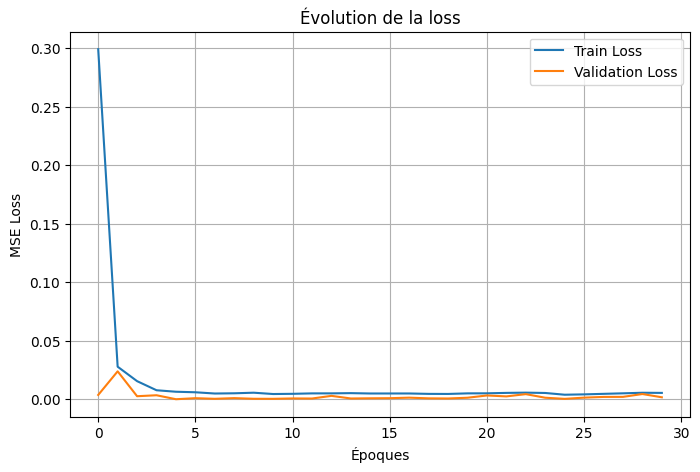

In [15]:


plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Évolution de la loss")
plt.xlabel("Époques")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [16]:


model.eval()

predictions = []
true_values = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        y_pred = model(X_batch)

        predictions.append(y_pred.cpu().numpy())
        true_values.append(y_batch.numpy())

predictions = np.vstack(predictions)
true_values = np.vstack(true_values)

predictions_real = scaler_y.inverse_transform(predictions)
true_values_real = scaler_y.inverse_transform(true_values)

r2 = r2_score(true_values_real, predictions_real)

print("Score R² sur le test :", r2)

Score R² sur le test : 0.3346693515777588


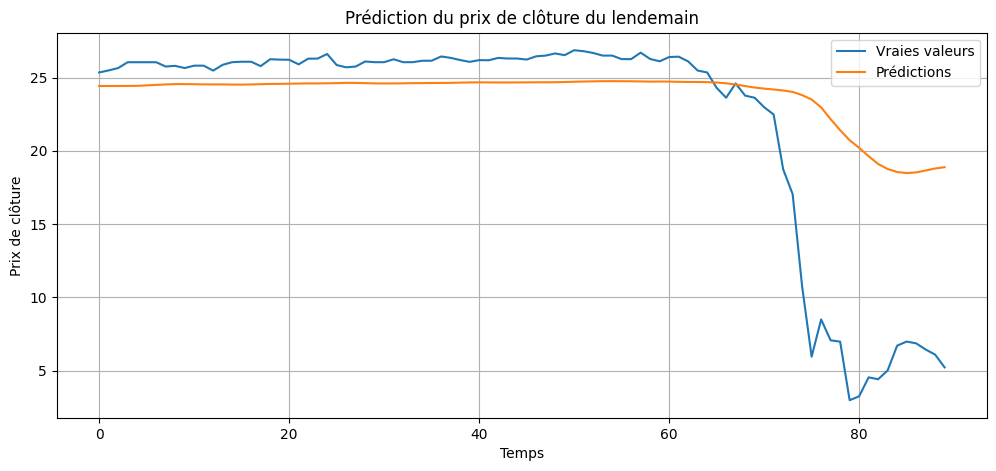

In [17]:


plt.figure(figsize=(12, 5))

plt.plot(true_values_real, label="Vraies valeurs")
plt.plot(predictions_real, label="Prédictions")

plt.title("Prédiction du prix de clôture du lendemain")
plt.xlabel("Temps")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)

plt.show()

In [18]:

import joblib

torch.save(model.state_dict(), "/content/drive/MyDrive/stock_lstm_model.pth")

joblib.dump(scaler_X, "/content/drive/MyDrive/scaler_X.pkl")
joblib.dump(scaler_y, "/content/drive/MyDrive/scaler_y.pkl")

print("Modèle et scalers sauvegardés avec succès.")

Modèle et scalers sauvegardés avec succès.


Dans cet exercice, nous avons construit un modèle LSTM avec PyTorch pour prédire le cours de clôture du lendemain à partir de données boursières. Nous avons commencé par charger et nettoyer le dataset, puis nous avons créé une colonne cible correspondant au prix de clôture du jour suivant.

Ensuite, nous avons normalisé les variables avec MinMaxScaler afin de faciliter l’apprentissage du modèle. Les données ont été transformées en séquences temporelles de 30 jours, car un LSTM apprend à partir d’un historique de valeurs passées.

Nous avons créé une classe Dataset personnalisée et utilisé DataLoader pour fournir les données au modèle par lots. Le modèle LSTM a été défini avec torch.nn.Module, une couche LSTM, du Dropout et une couche linéaire finale.

Après l’entraînement, nous avons évalué le modèle sur les données de test à l’aide du score R². Enfin, nous avons sauvegardé le modèle et les scalers afin de pouvoir les réutiliser pour de futures prédictions.